## Importação bibliotecas usadas na Análise Exploratória:


In [ ]:
import pandas as pd
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Carregando os Dados

In [3]:
df_leituras = pd.read_csv("Leituras.csv")

# Análise Exploratória dos Dados

In [13]:
# Primeiras 5 linhas
df_leituras.head()

,id,ts,temp_c,led_on,raw_adc,v_volts,rt_kohm,device_id,source
0,1749,2025-11-14 11:20:48.779657-03,23.12,False,NaN,NaN,NaN,esp8266-d2,serial
1,1748,2025-11-14 11:20:38.769008-03,23.29,False,NaN,NaN,NaN,esp8266-d2,serial
2,1747,2025-11-14 11:20:28.757392-03,23.21,False,NaN,NaN,NaN,esp8266-d2,serial
3,1746,2025-11-14 11:20:18.747619-03,23.29,False,NaN,NaN,NaN,esp8266-d2,serial
4,1745,2025-11-14 11:20:08.730921-03,23.40,False,NaN,NaN,NaN,esp8266-d2,serial


In [ ]:
# Shape
df_leituras.shape

(1728, 9)

In [7]:
# Identificando o tipo dos dados
df_leituras.dtypes

id             int64
ts            object
temp_c       float64
led_on          bool
raw_adc      float64
v_volts      float64
rt_kohm      float64
device_id     object
source        object
dtype: object

### Ajustando o DF 


> Deixando somente as colunas relevantes e renomeando elas:

In [4]:
# Atualizando o nome de colunas:
DF_leituras = pd.DataFrame({ 'id': df_leituras['id'],
                            'Data_Hora': df_leituras['ts'], 
                            'Temperatura_C': df_leituras['temp_c'],
                            'Fora_Faixa_Conforto': df_leituras['led_on']})

In [22]:
# Verificando:
DF_leituras.head()

,id,Data_Hora,Temperatura_C,Fora_Faixa_Conforto
0,1749,2025-11-14 11:20:48.779657-03,23.12,False
1,1748,2025-11-14 11:20:38.769008-03,23.29,False
2,1747,2025-11-14 11:20:28.757392-03,23.21,False
3,1746,2025-11-14 11:20:18.747619-03,23.29,False
4,1745,2025-11-14 11:20:08.730921-03,23.40,False


In [23]:
DF_leituras.dtypes

id                       int64
Data_Hora               object
Temperatura_C          float64
Fora_Faixa_Conforto       bool
dtype: object

### Ajustando o tipo de dado: 

> `Object` -->  `datetime`

(string) --> (data)

In [5]:
# Converte a coluna 'Data_Hora' para datetime
DF_leituras['Data_Hora'] = pd.to_datetime(DF_leituras['Data_Hora'], errors='coerce', utc=True)

# Ajusta o timezone para o horário local do Brasil (opcional)
DF_leituras['Data_Hora'] = DF_leituras['Data_Hora'].dt.tz_convert('America/Sao_Paulo')

In [26]:
# Checando 
DF_leituras.head()

,id,Data_Hora,Temperatura_C,Fora_Faixa_Conforto
0,1749,2025-11-14 11:20:48.779657-03:00,23.12,False
1,1748,2025-11-14 11:20:38.769008-03:00,23.29,False
2,1747,2025-11-14 11:20:28.757392-03:00,23.21,False
3,1746,2025-11-14 11:20:18.747619-03:00,23.29,False
4,1745,2025-11-14 11:20:08.730921-03:00,23.40,False


In [27]:
# Checando o tipo:
DF_leituras.dtypes

id                                                 int64
Data_Hora              datetime64[ns, America/Sao_Paulo]
Temperatura_C                                    float64
Fora_Faixa_Conforto                                 bool
dtype: object

### Análise Estatística:

<Axes: >

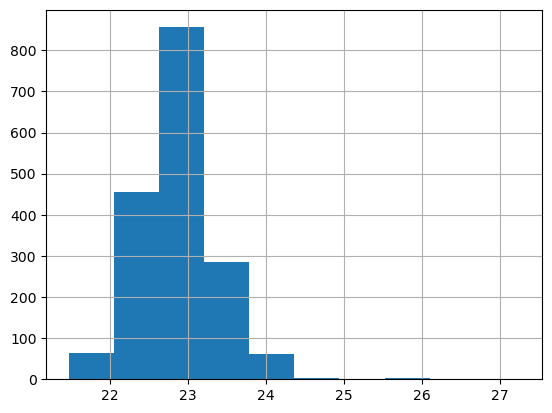

In [29]:
# Plot de Histograma
DF_leituras['Temperatura_C'].hist()

C:\Users\lucas\AppData\Local\Temp\ipykernel_26468\2776686230.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Fora_Faixa_Conforto', data=DF_leituras, palette=['#00b894','#d63031'])


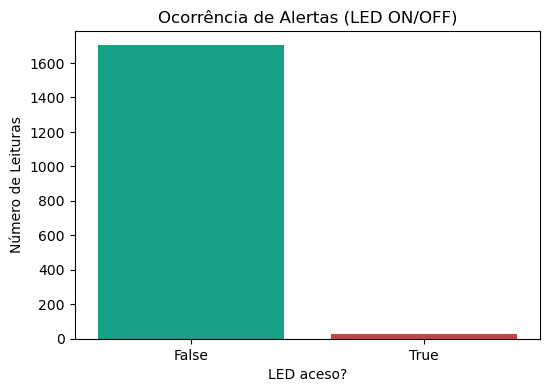

In [ ]:
# Análise dos Alertas (LED ON/OFF) - Faixa de Conforto
DF_leituras['Fora_Faixa_Conforto'] = DF_leituras['Fora_Faixa_Conforto'].astype(str).str.upper().isin(['TRUE', 'ON', '1'])

plt.figure(figsize=(6,4))
sns.countplot(x='Fora_Faixa_Conforto', data=DF_leituras, palette=['#00b894','#d63031'])
plt.title("Ocorrência de Alertas (LED ON/OFF)")
plt.xlabel("LED aceso?")
plt.ylabel("Número de Leituras")
plt.show()


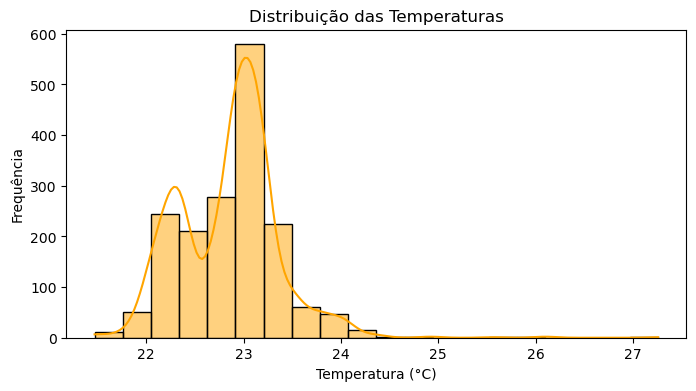

In [21]:
# Distribuição das Temperaturas:
plt.figure(figsize=(8,4))
sns.histplot(DF_leituras['Temperatura_C'], kde=True, bins=20, color='orange')
plt.title("Distribuição das Temperaturas")
plt.xlabel("Temperatura (°C)")
plt.ylabel("Frequência")
plt.show()

In [19]:
# Número de Leituras fora da Faixa de Conforto
num_fora = DF_leituras["Fora_Faixa_Conforto"].sum()
print(num_fora)

26


### Identificando **Outliers**:

In [32]:
# Resumo estatístico
DF_leituras['Temperatura_C'].describe()

count    1728.000000
mean       22.853628
std         0.515525
min        21.470000
25%        22.420000
50%        22.940000
75%        23.120000
max        27.260000
Name: Temperatura_C, dtype: float64

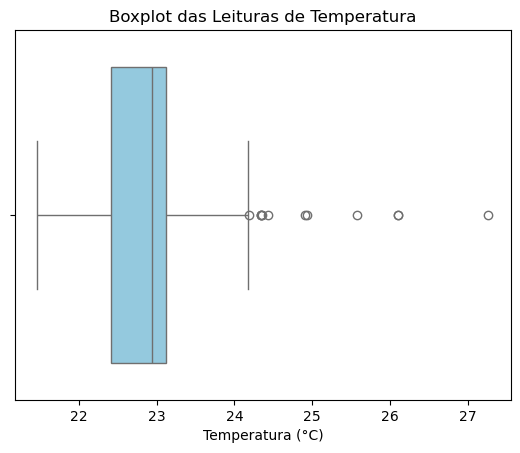

In [14]:
# Boxplot
sns.boxplot(x=DF_leituras['Temperatura_C'], color='skyblue')
plt.title("Boxplot das Leituras de Temperatura")
plt.xlabel("Temperatura (°C)")
plt.show()


In [ ]:
#  Visualizando os Outliers
outliers = [x for x in DF_leituras["Temperatura_C"] if x > 24]
print(outliers)

[25.57, 26.1, 24.08, 26.1, 24.93, 24.91, 27.26, 24.1, 24.08, 24.06, 24.34, 24.43, 24.34, 24.06, 24.08, 24.14, 24.09, 24.19, 24.16, 24.08, 24.08, 24.17, 24.05, 24.34, 24.35]


### Detectando se há **Valores Ausentes**:

In [35]:
# Shape
DF_leituras.shape

(1728, 4)

In [33]:
# Visualizando o total de linhas por coluna:
DF_leituras.count()

id                     1728
Data_Hora              1728
Temperatura_C          1728
Fora_Faixa_Conforto    1728
dtype: int64

In [1]:
# Soma de valores ausentes
valores_ausentes = DF_leituras.isnull().sum().sort_values(ascending = False)

NameError: name 'DF_leituras' is not defined

## CONCLUSÃO:

As leituras coletadas pelo ESP8266, enviadas via porta USB para o PowerShell e posteriormente armazenadas no banco de dados PostgreSQL por meio de um script Python, forneceram uma série temporal estável e consistente. Com o intervalo de 10 segundos entre cada amostra, foram registradas 1728 medições de temperatura no ambiente de trabalho.

Durante a Análise Exploratória de Dados, verificou-se que não houve falhas de leitura, pois o conjunto de dados não apresentou valores ausentes, corrompidos ou inconsistentes. A grande maioria das medições permaneceu dentro da faixa de conforto térmico definida (20 °C a 24 °C), havendo apenas 26 leituras fora desse intervalo, número considerado pequeno frente ao total coletado.

O resumo estatístico confirma a estabilidade térmica do ambiente: a temperatura média foi de 22,85 °C, com baixa variabilidade (desvio padrão de 0,51). Os valores mínimo (21,47 °C) e máximo (27,26 °C) mostram que o sistema respondeu adequadamente às mudanças, registrando inclusive pequenas variações naturais do ambiente.

Esses resultados demonstram que tanto o hardware quanto o pipeline de coleta, transmissão e armazenamento funcionaram corretamente, gerando dados confiáveis para as etapas seguintes do projeto, como construção de dashboards, identificação de padrões e interpretação dos resultados.